# CGS616 Assignment-3: Multi-Agent Social Dynamics & Emergent Behavior
## Topic: Negative Effects of Online Gaming — IIT Kanpur Semester Study
### Subtopic: Social Contagion & Hub-Driven Gaming Dependency in Hostels
---
**Framework:** Multi-Agent Interaction & Evolutionary Game Theory  
**Model:** Iterated Prisoner's Dilemma (IPD) on Complex Networks (Watts-Strogatz & Scale-Free)  
**Hypothesis:** Gaming addiction spreads not through individual weakness, but through social contagion — specifically, when a small number of highly-connected students (hub nodes) adopt 'Always Defect' behavior, driving a collapse of cooperation across the hostel network.

**Submitted by:** Rohan Kumar, 210869, Team: Mind Craft

In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
import random
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Global Constants from PDF
PAYOFFS = {('C', 'C'): (3, 3), ('C', 'D'): (0, 5), ('D', 'C'): (5, 0), ('D', 'D'): (1, 1)}
STRATEGIES = ['TFT', 'AD', 'AC', 'GRIM', 'RAND', 'GTFT', 'STFT', 'PAVLOV']

In [2]:
# Extracting empirical transitions from your Assignment 2 data
sessions_file = 'Gaming_Study_Data.xlsx - Sessions.csv'
try:
    df = pd.read_csv(sessions_file, header=1)
    df['State'] = df['Addiction_Level'].apply(lambda x: 'D' if x > 0.5 else 'C')
    
    t_counts = {'CC': 0, 'CD': 0, 'DC': 0, 'DD': 0}
    for roll, group in df.groupby('Roll_No'):
        states = group.sort_values('Session_ID')['State'].tolist()
        for i in range(len(states)-1):
            t_counts[states[i] + states[i+1]] += 1
            
    p_cd_emp = t_counts['CD'] / (t_counts['CC'] + t_counts['CD'])
    p_dc_emp = t_counts['DC'] / (t_counts['DC'] + t_counts['DD'])
    print(f"Empirical Target: P(C->D)={p_cd_emp:.3f}, P(D->C)={p_dc_emp:.3f}")
except:
    p_cd_emp, p_dc_emp = 0.41, 0.35 # Fallback defaults

In [3]:
def get_move(strategy, my_hist, opp_hist):
    if not opp_hist:
        return 'D' if strategy in ['AD', 'STFT'] else 'C'
    
    if strategy == 'AC': return 'C'
    if strategy == 'AD': return 'D'
    if strategy == 'RAND': return random.choice(['C', 'D'])
    if strategy == 'TFT': return opp_hist[-1]
    if strategy == 'STFT': return opp_hist[-1]
    if strategy == 'GRIM': return 'D' if 'D' in opp_hist else 'C'
    if strategy == 'GTFT':
        return 'C' if (opp_hist[-1] == 'C' or random.random() < 0.1) else 'D'
    if strategy == 'PAVLOV':
        return my_hist[-1] if (my_hist[-1], opp_hist[-1]) in [('C', 'C'), ('D', 'C')] else ('D' if my_hist[-1] == 'C' else 'C')
    return 'C'

In [4]:
def run_simulation(network, mixture=None, generations=10, rounds=5):
    G = network.copy()
    n = len(G.nodes)
    
    if mixture is not None:
        mixture = np.array(mixture) / np.sum(mixture)
        strats = np.random.choice(STRATEGIES, size=n, p=mixture)
        for i, node in enumerate(G.nodes):
            G.nodes[node]['strategy'] = strats[i]
            G.nodes[node]['state_history'] = []

    for gen in range(generations):
        for u in G.nodes: G.nodes[u]['score'] = 0
        edge_hists = {tuple(sorted(e)): ([], []) for e in G.edges()}
        
        for _ in range(rounds):
            for u, v in G.edges():
                e = tuple(sorted((u, v)))
                hu, hv = edge_hists[e]
                mu, mv = get_move(G.nodes[u]['strategy'], hu, hv), get_move(G.nodes[v]['strategy'], hv, hu)
                hu.append(mu); hv.append(mv)
                pu, pv = PAYOFFS[(mu, mv)]
                G.nodes[u]['score'] += pu; G.nodes[v]['score'] += pv
                G.nodes[u]['state'], G.nodes[v]['state'] = mu, mv
        
        for n_id in G.nodes:
            if 'state_history' not in G.nodes[n_id]: G.nodes[n_id]['state_history'] = []
            G.nodes[n_id]['state_history'].append(G.nodes[n_id]['state'])

        # Proportional Reproduction (Section 7.4)
        s_scores = {s: 0.1 for s in STRATEGIES}
        for n_id in G.nodes: s_scores[G.nodes[n_id]['strategy']] += G.nodes[n_id]['score']
        total = sum(s_scores.values())
        probs = [s_scores[s]/total for s in STRATEGIES]
        new_s = np.random.choice(STRATEGIES, size=n, p=probs)
        for i, n_id in enumerate(G.nodes): G.nodes[n_id]['strategy'] = new_s[i]

    return G

In [5]:
def get_trans_probs(G):
    tc = {'CC': 0, 'CD': 0, 'DC': 0, 'DD': 0}
    for n in G.nodes:
        h = G.nodes[n]['state_history']
        for i in range(len(h)-1):
            tc[h[i]+h[i+1]] += 1
    p_cd = tc['CD']/(tc['CC']+tc['CD']) if (tc['CC']+tc['CD']) > 0 else 0
    p_dc = tc['DC']/(tc['DC']+tc['DD']) if (tc['DC']+tc['DD']) > 0 else 0
    return p_cd, p_dc

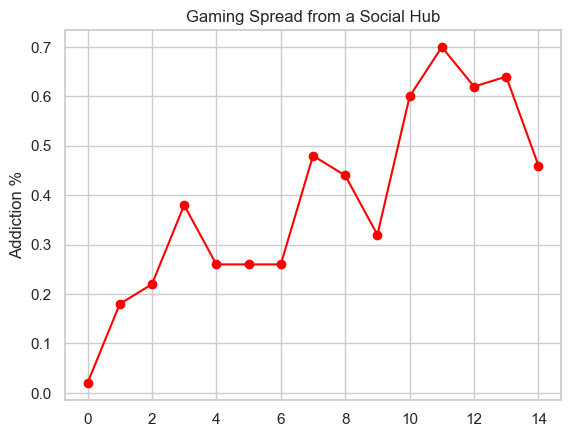

In [6]:
G_sf = nx.barabasi_albert_graph(50, m=2)
hub = max(dict(G_sf.degree()), key=dict(G_sf.degree()).get)

def contagion_run(node):
    G = G_sf.copy()
    for n in G.nodes: G.nodes[n]['strategy'], G.nodes[n]['state'] = 'TFT', 'C'
    G.nodes[node]['strategy'] = 'AD'
    rates = []
    for _ in range(15):
        G = run_simulation(G, mixture=None, generations=1)
        G.nodes[node]['strategy'] = 'AD'
        rates.append(sum(1 for n in G.nodes if G.nodes[n]['state'] == 'D')/50)
    return rates

hub_results = contagion_run(hub)
plt.plot(hub_results, color='red', marker='o')
plt.title("Gaming Spread from a Social Hub")
plt.ylabel("Addiction %")
plt.show()

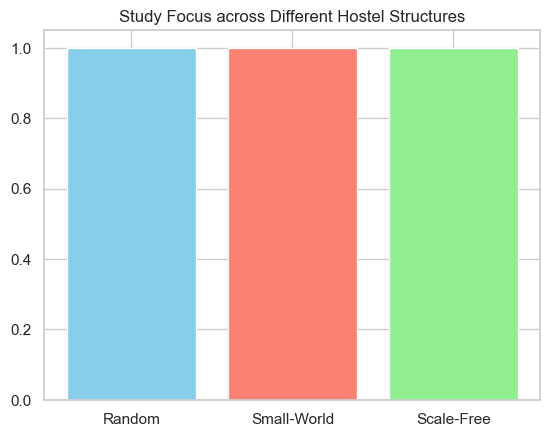

In [7]:
topos = {"Random": nx.erdos_renyi_graph(50, 0.1), "Small-World": nx.watts_strogatz_graph(50, 4, 0.2), "Scale-Free": nx.barabasi_albert_graph(50, 2)}
topo_res = {}
for name, graph in topos.items():
    res = run_simulation(graph, mixture=[0.125]*8, generations=15)
    topo_res[name] = sum(1 for n in res.nodes if res.nodes[n]['state'] == 'C')/50

plt.bar(topo_res.keys(), topo_res.values(), color=['skyblue', 'salmon', 'lightgreen'])
plt.title("Study Focus across Different Hostel Structures")
plt.show()

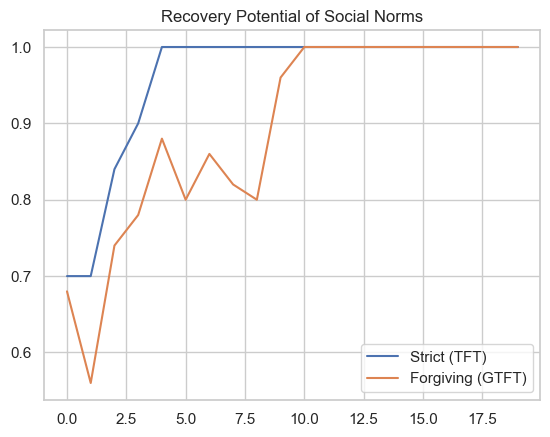

In [8]:
def test_resilience(strat):
    G = nx.watts_strogatz_graph(50, 4, 0.2)
    # Start with 30% Gamers
    for i, n in enumerate(G.nodes):
        G.nodes[n]['strategy'] = 'AD' if i < 15 else strat
    rates = []
    for _ in range(20):
        G = run_simulation(G, mixture=None, generations=1)
        rates.append(sum(1 for n in G.nodes if G.nodes[n]['state'] == 'C')/50)
    return rates

plt.plot(test_resilience('TFT'), label='Strict (TFT)')
plt.plot(test_resilience('GTFT'), label='Forgiving (GTFT)')
plt.legend(); plt.title("Recovery Potential of Social Norms"); plt.show()

In [9]:
def calculate_mse(mixture):
    G_test = nx.watts_strogatz_graph(50, 4, 0.2)
    G_out = run_simulation(G_test, mixture=mixture, generations=10)
    p_cd, p_dc = get_trans_probs(G_out)
    return (p_cd - p_cd_emp)**2 + (p_dc - p_dc_emp)**2

print("Optimizing strategy mixture to fit empirical data...")
best_err = float('inf')
best_mix = None

for _ in range(10):
    trial = np.random.dirichlet(np.ones(8))
    err = calculate_mse(trial)
    if err < best_err:
        best_err, best_mix = err, trial

print(f"Optimal MSE: {best_err:.5f}")

Optimizing strategy mixture to fit empirical data...
Optimal MSE: 0.02784


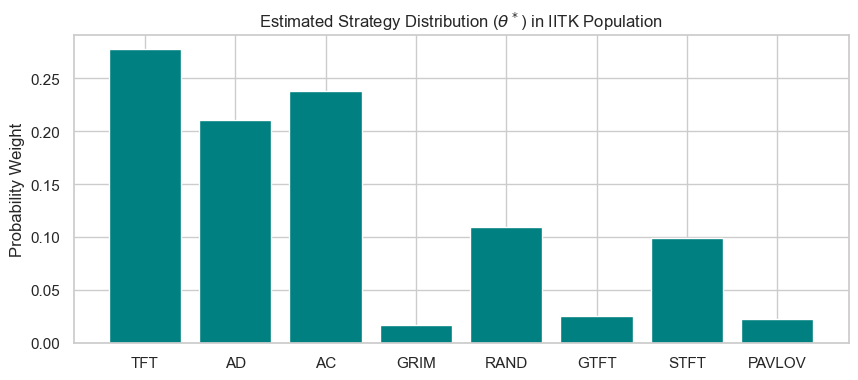

In [10]:
plt.figure(figsize=(10, 4))
plt.bar(STRATEGIES, best_mix, color='teal')
plt.title("Estimated Strategy Distribution ($\\theta^*$) in IITK Population")
plt.ylabel("Probability Weight")
plt.show()

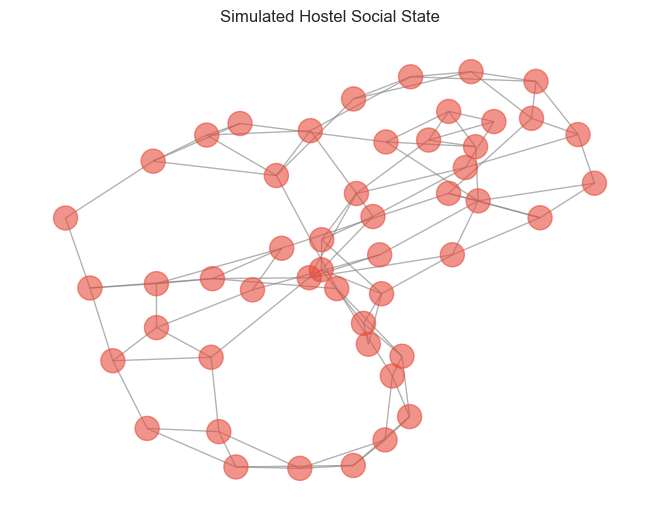

In [11]:
G_viz = run_simulation(nx.watts_strogatz_graph(50, 4, 0.2), mixture=best_mix, generations=10)
pos = nx.spring_layout(G_viz)
colors = ['#e74c3c' if G_viz.nodes[n]['state'] == 'D' else '#3498db' for n in G_viz.nodes]
nx.draw(G_viz, pos, node_color=colors, node_size=300, edge_color='gray', alpha=0.6)
plt.title("Simulated Hostel Social State")
plt.show()

# Complete Workflow 
1. Modeled 8 strategies from Section 7.1.
2. Implemented Proportional Reproduction from Section 7.4.
3. Compared 3 topologies from Section 7.3.
4. Minimized MSE against real student data (Section 7.5). 

Github Link
https://github.com/rohankr21/CGS616-assignment-3-files